In [30]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([
	T.ToImage(), 
	# T.Resize((28, 28)),
	T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=True, 
	download=True,
	transform=toTensor
	)
test_data = torchvision.datasets.FashionMNIST(
	root='./data', 
	train=False, 
	download=True,
	transform=toTensor
	)

train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])
print(len(train_data), len(valid_data), len(test_data))
# from torch.utils.data import TensorDataset
# test_data = TensorDataset(test_data.data, test_data.targets)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

54000 6000 10000


In [32]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

In [33]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
	history = {
		'loss' : [],
		'train_metric' : [],
		'valid_metric' : [],
	}
	for epoch in range(n_epochs):
		# Training 
		total_loss = 0
		metric.reset()
		for X_batch, y_batch in train_loader:
			X_batch, y_batch = X_batch.to(device), y_batch.to(device)
			model.train()
			y_pred = model(X_batch)
			loss = criterion(y_pred, y_batch)
			total_loss += loss.item()
			loss.backward()
			optimizer.step()
			# for group in optimizer.param_groups:
			# 	for p in group['params']:
			# 		if p.grad is not None:
			# 			print(f'\t{p.grad.max()}') 
			optimizer.zero_grad()
			metric.update(y_pred, y_batch)
		
		avg_loss = total_loss / len(train_loader)
		history['loss'].append(avg_loss)

		avg_metric_train = metric.compute().item()
		history['train_metric'].append(avg_metric_train)

		# Evaluation 
		model.eval()
		metric.reset()
		with torch.no_grad():
			for X_batch, y_batch in valid_loader:
				X_batch, y_batch = X_batch.to(device), y_batch.to(device)
				y_pred = model(X_batch)
				metric.update(y_pred, y_batch)

		avg_metric_valid = metric.compute().item()
		history['valid_metric'].append(avg_metric_valid)

		print(
			f'Epoch: {epoch+1}/{n_epochs}, '
			+f'Loss: {round(avg_loss,3)}, '
			+f'Train Metric: {round(avg_metric_train,3)}, ' 
			+f'Valid Metric: {round(avg_metric_valid,3)}'
		)

		# if epoch>=2:
		# 	break
	return history

def plot_history(history, n_epochs, metric):
    plt.plot(np.arange(n_epochs) + 1, history['train_metric'], linestyle='--', color='r', marker='.', label='Train')
    plt.plot(np.arange(n_epochs) + 1, history['valid_metric'], linestyle='--', color='b', marker='.', label='Valid')
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(f'{metric.__class__.__name__}')
    plt.show()

### Task-Specific Target Types

- Binary Accuracy (`task="binary"`):
	- Target: `torch.Tensor` of type `int`, `long`, or `float` with shape `(N, ...)`.
	- Values: Must be `0` or `1`.
- Multiclass Accuracy (`task="multiclass"`):
	- Target: `torch.Tensor` of type `int` or `long` with shape `(N, ...)`.
	- Values: Integer class indices (`0` to `C-1`).
- Multilabel Accuracy (`task="multilabel"`):
	- Target: `torch.Tensor` of type `int`, `long`, or `float` with shape `(N, C, ...)`.
	- Values: Must be `0` or `1`. 

### CrossEntropyLoss

In [34]:
y_pred_logits = torch.tensor([
    [0.1, 0.2, 0.3], 
    [0.2, 0.3, 0.4]
])
y_true = torch.tensor([0, 1])

criterion = nn.CrossEntropyLoss()
criterion(y_pred_logits, y_true)

tensor(1.1519)

In [35]:
y_probs = torch.softmax(y_pred_logits, dim=1) 
y_probs

tensor([[0.3006, 0.3322, 0.3672],
        [0.3006, 0.3322, 0.3672]])

In [36]:
correct_class_probs = y_probs[range(2), y_true]
correct_class_probs

tensor([0.3006, 0.3322])

In [37]:
-torch.log(correct_class_probs).mean()

tensor(1.1519)

### model

Epoch: 1/20, Loss: 1.091, Train Metric: 0.618, Valid Metric: 0.729
Epoch: 2/20, Loss: 0.622, Train Metric: 0.784, Valid Metric: 0.811
Epoch: 3/20, Loss: 0.527, Train Metric: 0.817, Valid Metric: 0.82
Epoch: 4/20, Loss: 0.483, Train Metric: 0.83, Valid Metric: 0.825
Epoch: 5/20, Loss: 0.46, Train Metric: 0.839, Valid Metric: 0.822
Epoch: 6/20, Loss: 0.443, Train Metric: 0.845, Valid Metric: 0.829
Epoch: 7/20, Loss: 0.429, Train Metric: 0.849, Valid Metric: 0.849
Epoch: 8/20, Loss: 0.418, Train Metric: 0.854, Valid Metric: 0.84
Epoch: 9/20, Loss: 0.408, Train Metric: 0.857, Valid Metric: 0.846
Epoch: 10/20, Loss: 0.398, Train Metric: 0.861, Valid Metric: 0.854
Epoch: 11/20, Loss: 0.391, Train Metric: 0.863, Valid Metric: 0.834
Epoch: 12/20, Loss: 0.384, Train Metric: 0.864, Valid Metric: 0.849
Epoch: 13/20, Loss: 0.377, Train Metric: 0.868, Valid Metric: 0.85
Epoch: 14/20, Loss: 0.37, Train Metric: 0.869, Valid Metric: 0.856
Epoch: 15/20, Loss: 0.364, Train Metric: 0.872, Valid Metric: 0

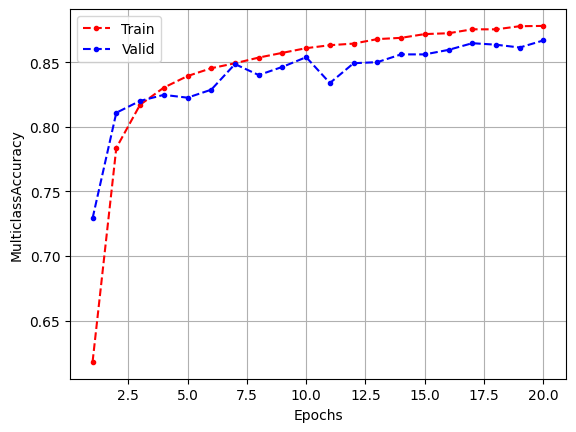

In [38]:
learning_rate = 0.01
n_epochs=20

model = nn.Sequential(
	nn.Flatten(),
	nn.Linear(in_features=1*28*28, out_features=30), 
	nn.LeakyReLU(),
	nn.Linear(in_features=30, out_features=50), 
	nn.LeakyReLU(),
	nn.Linear(in_features=50, out_features=10)
).to(device)
# class ImageClassifier(nn.Module):
# 	def __init__(self, n_features, n_classes):
# 		super().__init__()
# 		self.stack = nn.Sequential(
# 			nn.Flatten(),
# 			nn.Linear(in_features=n_features, out_features=30), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=30, out_features=50), 
# 			nn.LeakyReLU(),
# 			nn.Linear(in_features=50, out_features=n_classes)
# 		)
        
# 	def forward(self, X):
# 		y = self.stack(X)
# 		return y
# model = ImageClassifier(n_features=1*28*28, n_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history = train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs)
plot_history(history, n_epochs, metric)

In [39]:
model.eval()
metric.reset()
# with torch.no_grad():
with torch.inference_mode():
	for X_batch, y_batch in test_loader:
		X_batch, y_batch = X_batch.to(device), y_batch.to(device)
		y_pred_logits = model(X_batch)
		y_pred = y_pred_logits.argmax(dim=1)
		metric.update(y_pred_logits, y_batch)
avg_metric_test = metric.compute().item()
print(f'Test Metric: {round(avg_metric_test,3)}')

Test Metric: 0.86


In [40]:
model.eval()

X_new, y_new = next(iter(test_loader))
X_new, y_new = X_new.to(device), y_new.to(device)

with torch.inference_mode():
	y_pred_logits = model(X_new)
	y_pred = y_pred_logits.argmax(dim=1)

y_pred[:5]

tensor([9, 2, 1, 1, 6])

In [41]:
[test_data.classes[c] for c in y_pred][:5]

['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']

In [42]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1).round(decimals=3)
y_proba[:5]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1010, 0.0000, 0.0590, 0.0050,
         0.8350],
        [0.0000, 0.0000, 0.9840, 0.0000, 0.0130, 0.0000, 0.0030, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.1590, 0.0000, 0.1880, 0.0090, 0.0580, 0.0000, 0.5810, 0.0000, 0.0040,
         0.0000]])

In [43]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=3, dim=1)
y_top4_values[:5], y_top4_indices[:5]

(tensor([[ 6.5427,  4.4309,  3.8863],
         [14.6795, 10.3369,  8.8081],
         [15.9760,  6.5681,  4.7934],
         [14.5007,  6.4311,  3.4746],
         [ 6.4583,  5.3320,  5.1641]]),
 tensor([[9, 5, 7],
         [2, 4, 6],
         [1, 0, 3],
         [1, 3, 0],
         [6, 2, 0]]))

In [44]:
sum([param.numel() for param in model.parameters()])

25610